# Trabalho 5

This work explores the mapping algorithm for laser-ranger type sensors, which can be extended to lidars as well. The main issue with these algorithms is efficiency, in terms of computation and memory. Indeed, rasterization is required to map teh environment and the brute force approach algorithm swipes over the whole raster to update the likelyhood of a small number of map-pixels.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Image
from matplotlib.animation import FuncAnimation

# local imports
sys.path.append(os.path.abspath(r"../util/"))


from geometry import Segment, Pose, Angle
from robot import Robot
from maps import ObstacleMap, OccupancyGrid
from range_finder import RangeFinders
from control import VelocityControl, generateConstantVelocityTrajectory


## Initialze the Maps
In this example we work with a groundtruth / actual environment that is defined with segments, to improve the raycasting's efficiency, as presented in the previous work. 
The occupancy grid is for memory efficiency a dicitonary of points, paired to a likelihood value, where only the points with the likelihood different from the unexplored / initial value are stored.

In [3]:
#initialize environment and map
env = ObstacleMap(
    [
        Segment((-5, 5), (5, 5)),
        Segment((5, -5), (5, 5)),
        Segment((-5, 5), (-5, -4)),

        Segment((-5, -4), (-4, -4)),
        Segment((-4, -5), (-4, -4)),
        Segment((-5, -1), (-3, -1)),

        Segment((-3, 2.5), (-1, 2.5)),
        Segment((-2, 1.5), (-2, 3.5)),
        Segment((0.5, 5), (2, 1)),

        Segment((3, 3), (3, 5)),
        Segment((4, 1), (5, 1)),
        Segment((-1, -1), (0, -1)),

        Segment((0, -1), (0, -5)),
        Segment((1.5, -1.5), (3.5, -3.5)),
        Segment((1.5, -3.5), (3.5, -1.5)),
    ],
    x_lims=(-5, 5),
    y_lims=(-5, 5)
)

o_grid_resolution = 0.1
x_roi = (-5,5)
y_roi = (-5,5)
o_grid = OccupancyGrid(x_roi, y_roi, o_grid_resolution)

## Simulation Parameters

In [4]:
#set initial position
x0 = Pose(0., 0., Angle.from_deg(0.))

#set dt for simulation
dt = 0.05

## Deinition of the Sensor
In this example we implement a very rudimentary collision avoidance algorithm that makes use of the sensor's readings. It implements a P-Controller that adjusts the $\omega$ and $v$ velocieties of the control input, before applying it.

In [ ]:
#define sensor:
front_left   = Pose(0, 0.5, Angle(np.pi/6))
front_right  = Pose(0, -0.5, Angle(- np.pi/6))
front_center = Pose(0.5, 0, Angle(0.))
back_left    = Pose(-0.5, 0, Angle(np.pi - np.pi/6))
back_right   = Pose(-0.5, 0, Angle(np.pi + np.pi/6))

range_finder = RangeFinders(
    [
        front_left,
        front_right,
        front_center,
        back_left,
        back_right,        
    ],
    beam_fov=Angle.from_deg(2),
    robot_pose=x0
)

min_dist_to_wall = 1
v_max = 2
w_max = np.pi / 4
w_rotate = np.pi / 6
rotate_angle_when_in_front_of_obstacle = np.pi / 8
rot_time = rotate_angle_when_in_front_of_obstacle / w_rotate
rot_sign = 1
iter_to_rotate =  rot_time / dt
rotated_iter = iter_to_rotate

#implement collision avoidance
def collisionAvoidance(u: VelocityControl):
    global range_finder, min_dist_to_wall, v_max, w_max, rotate_angle_when_in_front_of_obstacle, rotated_iter, iter_to_rotate, w_rotate, rot_sign

    k_fl = 10
    k_bl = 0.1
    k_fr = 10
    k_br = 0.
    k_fc = 1.2
    k_bc = 0.

    min_dist_to_rot = 0.1

    def zero_clip(val, clip_val):
        if val > clip_val: return 0
        else: return val

    if rotated_iter < iter_to_rotate:
        u.w = w_rotate
        u.v = 0
        rotated_iter += 1
    else:
        fl = zero_clip(range_finder.z_rangers[0].reading.r, min_dist_to_wall)
        fr = zero_clip(range_finder.z_rangers[1].reading.r, min_dist_to_wall)
        fc = zero_clip(range_finder.z_rangers[2].reading.r, min_dist_to_wall)
        bl = zero_clip(range_finder.z_rangers[3].reading.r, min_dist_to_wall)
        br = zero_clip(range_finder.z_rangers[4].reading.r, min_dist_to_wall)
        bc = zero_clip(np.sqrt(br**2 + bl**2) / 2,          min_dist_to_wall)

        fl_is_close_to_obj = (fl > 1e-6 and fl < np.cos(np.pi/6) + min_dist_to_rot)
        fr_is_close_to_obj = (fr > 1e-6 and fr < np.cos(np.pi/6) + min_dist_to_rot)
        fc_is_close_to_obj = (fc > 1e-6 and fc < min_dist_to_rot)
        
        if fl_is_close_to_obj or fr_is_close_to_obj or fc_is_close_to_obj:
            rotated_iter = 0                           
            u.w = w_rotate
            u.v = 0

            return u

        fl = min_dist_to_wall - fl if fl > 0. else 0 
        fr = min_dist_to_wall - fr if fr > 0. else 0 
        fc = min_dist_to_wall - fc if fc > 0. else 0 
        bl = min_dist_to_wall - bl if bl > 0. else 0 
        br = min_dist_to_wall - br if br > 0. else 0 
        bc = min_dist_to_wall - bc if bc > 0. else 0 

        turn_right = k_fl * fl + k_bl * bl
        turn_left  = k_fr * fr + k_br * br

        w_corr = turn_left - turn_right
        v_corr = k_bc * bc - k_fc * fc

        v_new = np.clip(u.v + v_corr, 0., v_max)
        w_new = np.clip(u.w + w_corr, -w_max, w_max)

        if v_new < 1e-6 and u.v > 1e-6: 
            rotated_iter = 0
            u.w = w_rotate
            u.v = 0
        else:
            u.w = w_new
            u.v = v_new

    return u


## Initialization of the Robot
The robot is initialized at given initila position, with the sensor defined above and the collision avoidance algorithm

In [6]:
#define the robot
robot = Robot(
    x0, 
    sensors = [
        range_finder
    ],
    collisionAvoidance = collisionAvoidance 
)

# Plot of the initial state
The robot in its initial state is shown, along with the range finder's measurements. Furhtermore the updated occupancy grid after the the first taken measurement

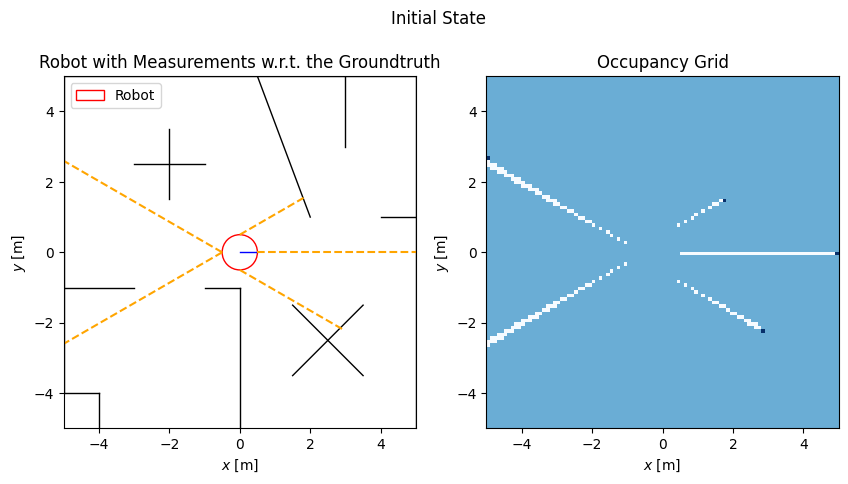

In [7]:
robot.measure(env)
range_finder.update_occupancy_grid(o_grid)

#plot initial state, with first measurement
f = plt.figure(figsize=(10, 5))
f.suptitle("Initial State")

ax1 = plt.subplot(1,2, 1)
ax1.set_title("Robot with Measurements w.r.t. the Groundtruth")
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m]")
env.draw(ax1)
robot.draw(ax1, r = 0.5)

ax2 = plt.subplot(1,2, 2)
ax2.set_title("Occupancy Grid")
ax2.set_xlabel("$x$ [m]")
ax2.set_ylabel("$y$ [m]")
o_grid.drawImg(ax2)

In [ ]:

animation_time = 30 #[s]

n_frames = int(animation_time / dt)
#trajectory = generateRandomVelocityTrajectory(n_frames,dt)
trajectory = generateConstantVelocityTrajectory(n_frames, 0.5, 0., dt)
applied_controls = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.draw(ax1)
ax1.set_aspect('equal', adjustable='box')
ax1.set_title("Robot with Measurements w.r.t. the Groundtruth")
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m]")

ax2.set_title("Occupancy Grid")
ax2.set_xlabel("$x$ [m]")
ax2.set_ylabel("$y$ [m]")
#update function for animation
def update(frame):
    global applied_controls
    ax2.clear()
    ax1.clear()
    
    u = trajectory[frame]

    applied_controls.append(robot.applyControl(u))

    robot.measure(env)
    range_finder.update_occupancy_grid(o_grid)

    env.draw(ax1)
    robot.draw(ax1, r = 0.5)

    o_grid.drawImg(ax2)
    

ani = FuncAnimation(fig, update, frames=np.arange(0, n_frames), interval=50)

gif_path = 'img/knownCorr.gif'
ani.save(gif_path, writer='pillow', fps=20)

plt.close(fig)

display(Image(filename=gif_path))

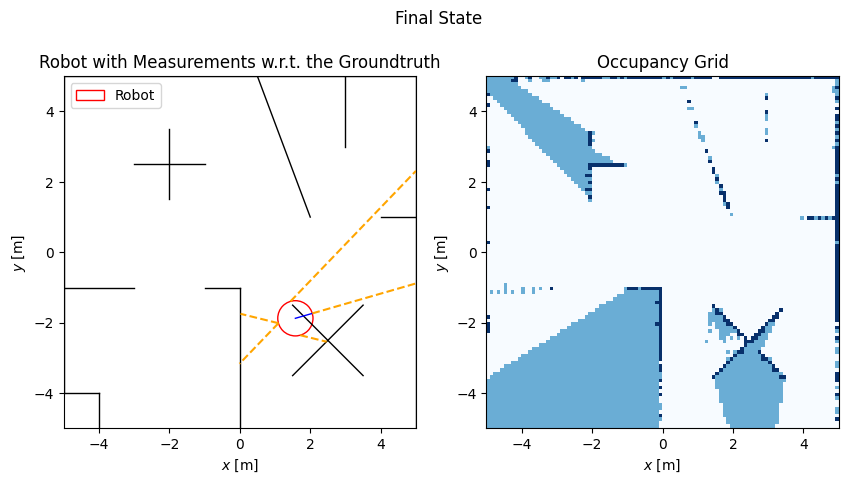

In [ ]:
#plot final state, with first measurement
f = plt.figure(figsize=(10, 5))
f.suptitle("Final State")

ax1 = plt.subplot(1,2, 1)
ax1.set_title("Robot with Measurements w.r.t. the Groundtruth")
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m]")
env.draw(ax1)
robot.draw(ax1, r = 0.5)

ax2 = plt.subplot(1,2, 2)
ax2.set_title("Occupancy Grid")
ax2.set_xlabel("$x$ [m]")
ax2.set_ylabel("$y$ [m]")
o_grid.drawImg(ax2)

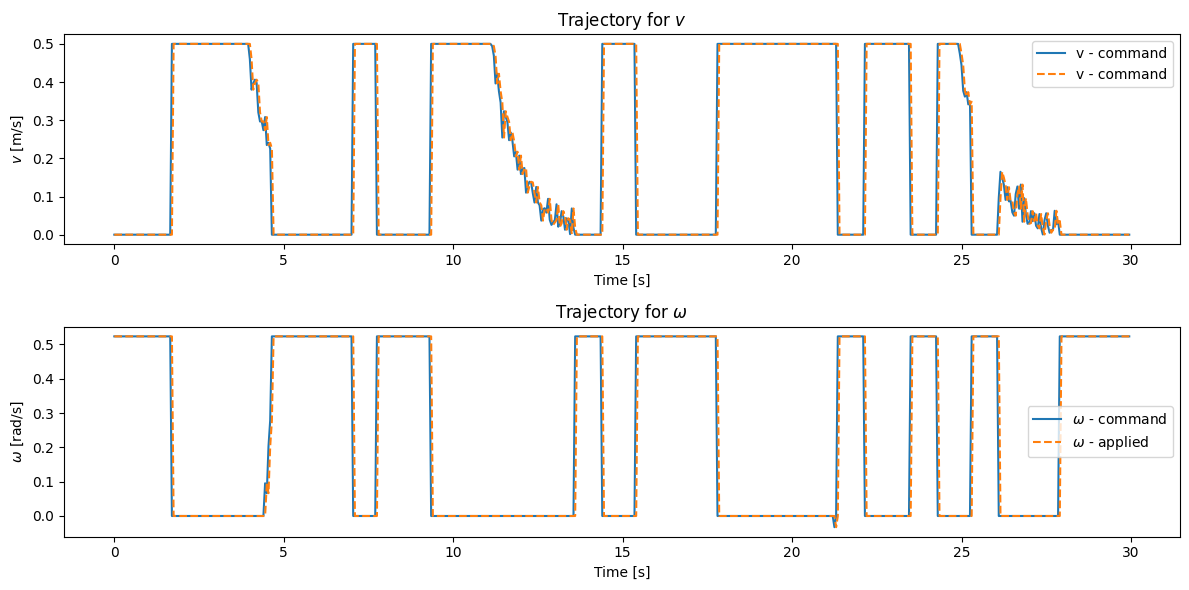

In [ ]:
v_traj= []
w_traj = []
v_eff_traj = []
w_eff_traj = []
t_traj = []

t = 0
for u, u_eff in zip(trajectory, applied_controls):
    t_traj.append(t)
    v_traj.append(u.v)
    w_traj.append(u.w) 
    v_eff_traj.append(u_eff.v) 
    w_eff_traj.append(u_eff.w) 
    t += dt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.set_title("Trajectory for $v$")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel(r"$v$ [m/s]")

ax2.set_title("Trajectory for $\\omega$")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel(r"$\omega$ [rad/s]")

ax1.plot(t_traj, v_traj, label="v - command")
ax1.plot(t_traj, v_eff_traj, linestyle='--', label="v - command")
ax1.legend()

ax2.plot(t_traj, w_traj, label="$\\omega$ - command")
ax2.plot(t_traj, w_eff_traj, linestyle='--', label="$\\omega$ - applied")
ax2.legend()
plt.tight_layout()